In [12]:
# 1.) Importing the neccessary files.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 2.) Loading the dataset.
df = pd.read_csv('/content/imdb_top_1000.csv')

In [14]:
# 3.) Cleaning and preprocessing the data.
df['Gross'] = df['Gross'].str.replace(',', '').astype(float)

# Clean 'Released_Year': Convert to numeric (handles non-numeric strings as NaN)
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

# Fill missing Meta_score and Gross with their median values
df['Meta_score'] = df['Meta_score'].fillna(df['Meta_score'].median())
df['Gross'] = df['Gross'].fillna(df['Gross'].median())

In [15]:
# 4.) Summary of the dataset.
print(f"--- Summary Statistics for IMDB Ratings ---")
print(f"Mean Rating: {df['IMDB_Rating'].mean():.2f}")
print(f"Median Rating: {df['IMDB_Rating'].median():.2f}")
print(f"Mode Rating: {df['IMDB_Rating'].mode()[0]:.2f}\n")

--- Summary Statistics for IMDB Ratings ---
Mean Rating: 7.95
Median Rating: 7.90
Mode Rating: 7.70



In [16]:
# 5.) Visualizations.
sns.set(style="whitegrid")

**Histogram**

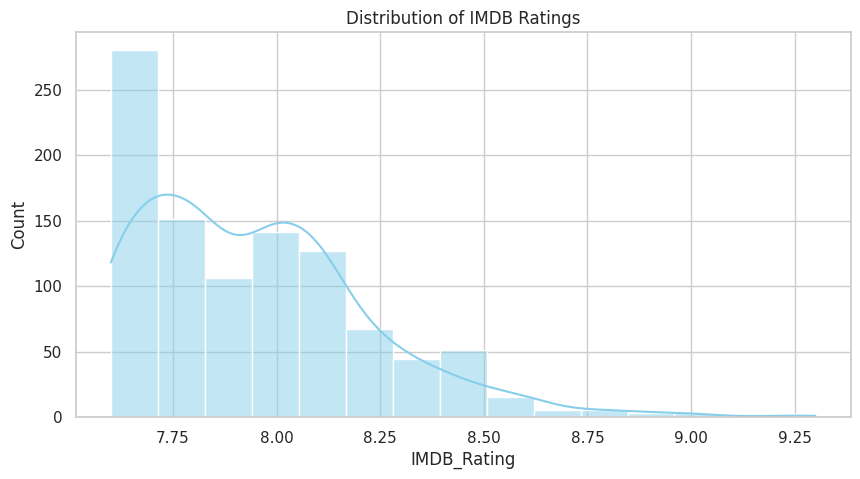

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(df['IMDB_Rating'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of IMDB Ratings')
plt.savefig('rating_distribution.png')

**Box Plot**

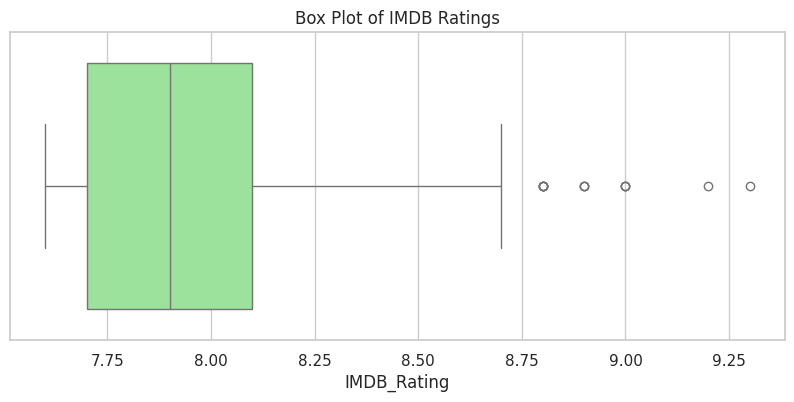

In [9]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['IMDB_Rating'], color='lightgreen')
plt.title('Box Plot of IMDB Ratings')
plt.savefig('rating_boxplot.png')

/tmp/ipython-input-1396512591.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


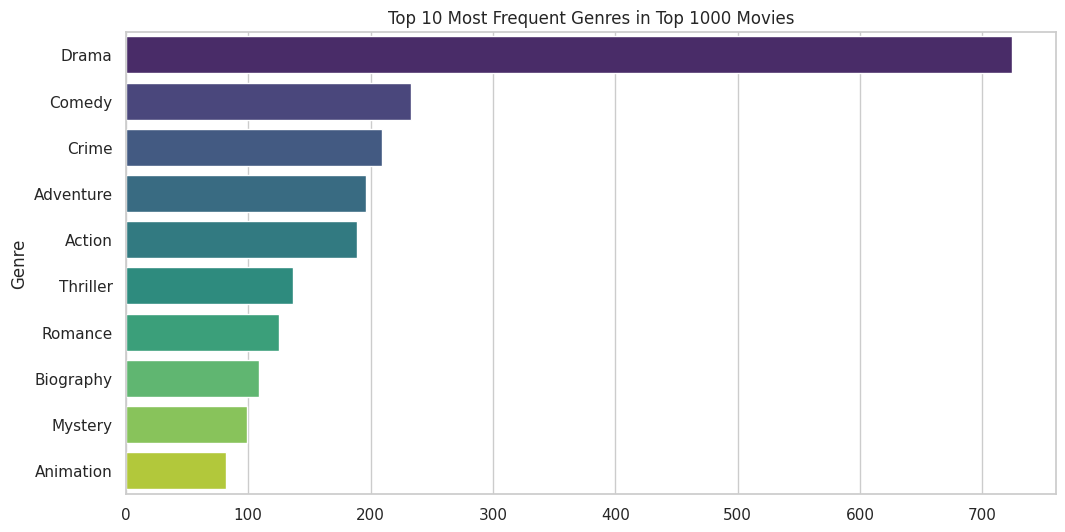

In [10]:
# 6.) Analyzing the genres of the movies.
# Explode genres so each genre has its own row for analysis
df_exploded = df.copy()
df_exploded['Genre'] = df_exploded['Genre'].str.split(', ')
df_exploded = df_exploded.explode('Genre')

# Top 10 Most Frequent Genres
top_genres = df_exploded['Genre'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Most Frequent Genres in Top 1000 Movies')
plt.savefig('top_genres.png')

In [17]:
# 7.) Identifying the top movies.
top_10_movies = df[['Series_Title', 'IMDB_Rating']].sort_values(by='IMDB_Rating', ascending=False).head(10)
print("--- Top 10 Rated Movies ---")
print(top_10_movies)

plt.show()

--- Top 10 Rated Movies ---
                                     Series_Title  IMDB_Rating
0                        The Shawshank Redemption          9.3
1                                   The Godfather          9.2
4                                    12 Angry Men          9.0
2                                 The Dark Knight          9.0
3                          The Godfather: Part II          9.0
5   The Lord of the Rings: The Return of the King          8.9
7                                Schindler's List          8.9
6                                    Pulp Fiction          8.9
8                                       Inception          8.8
12                Il buono, il brutto, il cattivo          8.8
